# **# Detecting SQL Injection Attacks with NLP: A Comparative Study of Classical and Transformer-Based Models Under Evasion Conditions**

##Data Import and CLeaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Connected my drive where SQL data used for testing is located.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The dataset used in this study was compiled from multiple publicly available sources. SQL query data was obtained from Kaggle datasets, along with SQL injection payloads inspired by OWASP guidelines and publicly available “Top 100” SQL injection samples.

These sources were combined into a unified dataset called Modified_SQL_Dataset.csv, in where the individual labeled samples were merged and randomly shuffled to reduce ordering bias. The dataset was then split into training, validation, and testing subsets. Approximately 60% of each files are clean SQL queries and 40% are labeled as SQLi.

Each subset was imported into the notebook as a Pandas DataFrame for preprocessing, model training, and evaluation.


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/data/Train.csv")
val = pd.read_csv("/content/drive/MyDrive/data/Validation.csv")
test = pd.read_csv("/content/drive/MyDrive/data/Test.csv")


Results of the Labels used which are 0 and 1 and the proportions used for each sample. Label of 0 is normal SQL queries. A label of 1 is SQLi Queries.

In [ ]:
print(train['Label'].value_counts(normalize=True))
print(val['Label'].value_counts(normalize=True))
print(test['Label'].value_counts(normalize=True))
print(train.shape)
print(val.shape)
print(test.shape)


Label
0    0.633323
1    0.366677
Name: proportion, dtype: float64
Label
0    0.645752
1    0.354248
Name: proportion, dtype: float64
Label
0    0.611255
1    0.388745
Name: proportion, dtype: float64
(21643, 2)
(4638, 2)
(4638, 2)


In [ ]:
DataFrame Representation of Query to Label.

In [ ]:
train.groupby('Label').head(3)

,Query,Label
0,SELECT those FROM rear,0
1,"SELECT Orders.layersrID, Employees.when, Emp...",0
2,"SELECT feelID AS ID, sick AS flag FROM possible",0
4,"1 ) ) ) and elt ( 3114 = 3114,s...",1
6,"-5798"" or 5023 = ctxsys.drithsx.sn ( 5023,...",1
7,"1%"" ) ) ) union all select null,nul...",1


Python script to select Queries labeld as 1 within the test data frame and convert them lexical obfuscation by changing its representation by case, adding white spaces, and inserting comments.

In [ ]:
import random
import re

def random_case(s):
    return "".join(
        c.upper() if random.random() > 0.5 else c.lower()
        for c in s
    )

def inject_spaces(s):
    tokens = s.split()
    return " ".join(token + (" " * random.randint(1, 3)) for token in tokens)

def insert_comments(s):
    keywords = ["SELECT", "UNION", "OR", "AND", "WHERE"]
    for kw in keywords:
        s = re.sub(rf"\b{kw}\b", lambda m: m.group(0) + "/**/", s, flags=re.IGNORECASE)
    return s

def create_obfuscated_df(df, transform_func):
    new_df = df.copy()
    mask = new_df["Label"] == 1
    new_df.loc[mask, "Query"] = new_df.loc[mask, "Query"].apply(transform_func)
    return new_df

def combined_obfuscation(s):
    s = random_case(s)
    s = inject_spaces(s)
    s = insert_comments(s)
    return s

test_combined_df = create_obfuscated_df(test, combined_obfuscation)

Below are validation and sample representation to verify the changes occured appropriately.

In [ ]:
test_combined_df.shape

(4638, 2)

In [ ]:
changed = (test["Query"] != test_combined_df["Query"]).sum()
print("Changed rows:", changed)

Changed rows: 1803


In [ ]:
test_combined_df.groupby('Label').head(3)

,Query,Label
0,SELECT * FROM anybody WHERE full = 'buffalo' ...,0
1,1%' ) ) ) aND/**/ SleeP ( 5 )...,1
2,SELECT metal ( s ) FROM involved LEFT JOIN,0
3,veronese vitte,0
4,1' Where/**/ 8860 = 8860 And/**/ ...,1
10,"1%"" or/**/ ChAr ( 75 ) ||ChaR ( ...",1


Created an new test set by converting SQLi labeled queries to URL Encoding with each chracter being represented as two hexadecimal numbers with a % sign indicating hexadecimal representation.

In [ ]:
import urllib.parse

def url_encode(s):
    return urllib.parse.quote(s)

test_url_df = create_obfuscated_df(test, url_encode)

for i in range(5):
    orig = test.loc[test["Label"] == 1, "Query"].iloc[i]
    obf = test_url_df.loc[test_url_df["Label"] == 1, "Query"].iloc[i]

    print("ORIGINAL:", orig)
    print("ENCODED:", obf)
    print("-" * 50)

ORIGINAL: 1%'   )    )     )   and sleep  (  5  )   and    (    (     (  '%'  =  '
ENCODED: 1%25%27%20%20%20%29%20%20%20%20%29%20%20%20%20%20%29%20%20%20and%20sleep%20%20%28%20%205%20%20%29%20%20%20and%20%20%20%20%28%20%20%20%20%28%20%20%20%20%20%28%20%20%27%25%27%20%20%3D%20%20%27
--------------------------------------------------
ORIGINAL: 1' where 8860  =  8860 and extractvalue  (  7982,concat  (  0x5c,0x7171706a71,  (  select   (  elt  (  7982  =  7982,1   )    )     )  ,0x717a767a71   )    )   --
ENCODED: 1%27%20where%208860%20%20%3D%20%208860%20and%20extractvalue%20%20%28%20%207982%2Cconcat%20%20%28%20%200x5c%2C0x7171706a71%2C%20%20%28%20%20select%20%20%20%28%20%20elt%20%20%28%20%207982%20%20%3D%20%207982%2C1%20%20%20%29%20%20%20%20%29%20%20%20%20%20%29%20%20%2C0x717a767a71%20%20%20%29%20%20%20%20%29%20%20%20--
--------------------------------------------------
ORIGINAL: 1%" or char  (  75  )  ||char  (  70  )  ||char  (  99  )  ||char  (  83  )    =  regexp_substring  (  repeat 

##TF-IDF Logistic Regression Classical Machine Learning Model

LR MODEL TESTING Verison 1 Clean Normal Test set

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train = train['Query']
y_train = train['Label']

X_val = val['Query']
y_val = val['Label']

X_test = test['Query']
y_test = test['Label']

X_test_combined = test_combined_df['Query']
y_test_combined = test_combined_df['Label']

X_url= test_url_df['Query']
y_url = test_url_df['Label']

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)
X_test_combined_tfidf = tfidf.transform(X_test_combined)
X_url_tfidf = tfidf.transform(X_url)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

# Validation predictions
y_val_pred = lr_model.predict(X_val_tfidf)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nValidation Classification Report:\n")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.9898663216903838

Validation Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2995
           1       0.99      0.98      0.99      1643

    accuracy                           0.99      4638
   macro avg       0.99      0.99      0.99      4638
weighted avg       0.99      0.99      0.99      4638

Validation Confusion Matrix:
 [[2984   11]
 [  36 1607]]


LR Testing Lexical Obfuscation Test 2

In [ ]:
# Test predictions
y_test_pred = lr_model.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.9864165588615783

Test Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2835
           1       0.99      0.97      0.98      1803

    accuracy                           0.99      4638
   macro avg       0.99      0.98      0.99      4638
weighted avg       0.99      0.99      0.99      4638

Test Confusion Matrix:
 [[2822   13]
 [  50 1753]]


In [ ]:
# Test predictions

y_test_combined_pred = lr_model.predict(X_test_combined_tfidf)

print("Test Accuracy:", accuracy_score(y_test_combined, y_test_combined_pred))
print("\nTest Classification Report:\n")
print(classification_report(y_test_combined, y_test_combined_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test_combined, y_test_combined_pred))

Test Accuracy: 0.9864165588615783

Test Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2835
           1       0.99      0.97      0.98      1803

    accuracy                           0.99      4638
   macro avg       0.99      0.98      0.99      4638
weighted avg       0.99      0.99      0.99      4638

Test Confusion Matrix:
 [[2822   13]
 [  50 1753]]


LR Testing URL Encoded SQLi Test 3

In [ ]:
y_url_pred = lr_model.predict(X_url_tfidf)

print("Test Accuracy:", accuracy_score(y_url, y_url_pred))
print("\nTest Classification Report:\n")
print(classification_report(y_url, y_url_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_url, y_url_pred))

Test Accuracy: 0.6093143596377749

Test Classification Report:

              precision    recall  f1-score   support

           0       0.61      1.00      0.76      2835
           1       0.24      0.00      0.00      1803

    accuracy                           0.61      4638
   macro avg       0.42      0.50      0.38      4638
weighted avg       0.46      0.61      0.46      4638

Test Confusion Matrix:
 [[2822   13]
 [1799    4]]


## CNN Deep Learning Model

CNN Model Creation and testing.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding

from tensorflow import keras

def build_cnn_model(num_filters, kernel_sizes, dense_layer_dims, dropout_rate, embeddings_trainable=True):
    cnn_input_layer = keras.layers.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int64')
    vocab_size = len(tokenizer.word_index) + 1
    cnn_embeddings = keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=100,
        trainable=embeddings_trainable
    )(cnn_input_layer)

    conv_layers_for_all_kernel_sizes = []
    for kernel_size, filters in zip(kernel_sizes, num_filters):
        conv_layer = keras.layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation='relu'
        )(cnn_embeddings)
        conv_layer = keras.layers.GlobalMaxPooling1D()(conv_layer)
        conv_layers_for_all_kernel_sizes.append(conv_layer)

    conv_output = keras.layers.concatenate(conv_layers_for_all_kernel_sizes, axis=1)
    last_hidden_output = keras.layers.Dropout(rate=dropout_rate)(conv_output)

    for dense_layer_dim in dense_layer_dims:
        last_hidden_output = keras.layers.Dense(dense_layer_dim, activation='relu')(last_hidden_output)

    cnn_prediction = keras.layers.Dense(1, activation='sigmoid')(last_hidden_output)

    cnn_model = keras.Model(inputs=cnn_input_layer, outputs=cnn_prediction)
    cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return cnn_model

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_SEQUENCE_LENGTH = 100
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train['Query'])

train_seq = tokenizer.texts_to_sequences(train['Query'])
val_seq = tokenizer.texts_to_sequences(val['Query'])

train_input = pad_sequences(train_seq, maxlen=MAX_SEQUENCE_LENGTH)
val_input = pad_sequences(val_seq, maxlen=MAX_SEQUENCE_LENGTH)

train_labels = train['Label']
val_labels = val['Label']

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


num_filters = [32, 32, 32]
kernel_sizes = [3, 4, 5]
dense_layer_dims = [32]
dropout_rate = 0.5
embeddings_trainable = True

cnn_model3 = build_cnn_model(
    num_filters,
    kernel_sizes,
    dense_layer_dims,
    dropout_rate,
    embeddings_trainable
)

cnn_history3 = cnn_model3.fit(
    train_input,
    train_labels,
    validation_data=(val_input, val_labels),
    batch_size=32,
    epochs=5
)



Epoch 1/5
677/677 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9681 - loss: 0.0839 - val_accuracy: 0.9963 - val_loss: 0.0217
Epoch 2/5
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9958 - loss: 0.0193 - val_accuracy: 0.9966 - val_loss: 0.0223
Epoch 3/5
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9975 - loss: 0.0126 - val_accuracy: 0.9935 - val_loss: 0.0283
Epoch 4/5
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9975 - loss: 0.0123 - val_accuracy: 0.9959 - val_loss: 0.0247
Epoch 5/5
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9975 - loss: 0.0115 - val_accuracy: 0.9935 - val_loss: 0.0286


CNN Test 1 Clean SQL and SQLi data.

In [ ]:
test_seq = tokenizer.texts_to_sequences(test['Query'])
test_input = pad_sequences(test_seq, maxlen=MAX_SEQUENCE_LENGTH)
test_labels = test['Label']

test_loss, test_accuracy = cnn_model3.evaluate(test_input, test_labels)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

test_loss, test_accuracy = cnn_model3.evaluate(test_input, test_labels)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9916 - loss: 0.0254
Test Accuracy: 0.991591215133667
Test Loss: 0.025374675169587135
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9916 - loss: 0.0254
Test Accuracy: 0.991591215133667
Test Loss: 0.025374675169587135


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict probabilities
y_pred_probs = cnn_model3.predict(test_input, verbose=0)

# Convert probabilities to 0/1 labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# True labels
y_true = np.array(test_labels)

# Report
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2835
           1       0.99      0.99      0.99      1803

    accuracy                           0.99      4638
   macro avg       0.99      0.99      0.99      4638
weighted avg       0.99      0.99      0.99      4638

[[2812   23]
 [  16 1787]]


CNN Test 2 Lexical Obfuscation SQLi.

In [ ]:
test_combined_seq = tokenizer.texts_to_sequences(test_combined_df['Query'])
test_combined_input = pad_sequences(test_combined_seq, maxlen=MAX_SEQUENCE_LENGTH)
test_combined_labels = test_combined_df['Label']

test_combined_loss, test_combined_accuracy = cnn_model3.evaluate(test_combined_input, test_combined_labels)
print("Test Accuracy:", test_combined_accuracy)
print("Test Loss:", test_combined_loss)

test_combined_loss, test_combined_accuracy = cnn_model3.evaluate(test_combined_input, test_combined_labels)
print("Test Accuracy:", test_combined_accuracy)
print("Test Loss:", test_combined_loss)

145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9916 - loss: 0.0254
Test Accuracy: 0.991591215133667
Test Loss: 0.025374675169587135
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0254
Test Accuracy: 0.991591215133667
Test Loss: 0.025374675169587135


In [ ]:
# Predict probabilities
y_pred_combined_probs = cnn_model3.predict(test_combined_input, verbose=0)

# Convert probabilities to 0/1 labels
y_pred_combined = (y_pred_combined_probs > 0.5).astype(int).flatten()

# True labels
y_combined_true = np.array(test_combined_labels)

# Report
print(classification_report(y_combined_true, y_pred_combined))
print(confusion_matrix(y_combined_true, y_pred_combined))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2835
           1       0.99      0.99      0.99      1803

    accuracy                           0.99      4638
   macro avg       0.99      0.99      0.99      4638
weighted avg       0.99      0.99      0.99      4638

[[2812   23]
 [  16 1787]]


CNN Test 3 URL encoded SQLi.

In [ ]:
test_url_seq = tokenizer.texts_to_sequences(test_url_df['Query'])
test_url_input = pad_sequences(test_url_seq, maxlen=MAX_SEQUENCE_LENGTH)
test_url_labels = test_url_df['Label']

test_url_loss, test_url_accuracy = cnn_model3.evaluate(test_url_input, test_url_labels)
print("Test Accuracy:", test_url_accuracy)
print("Test Loss:", test_url_loss)

test_loss, test_accuracy = cnn_model3.evaluate(test_url_input, test_url_labels)
print("Test Accuracy:", test_url_accuracy)
print("Test Loss:", test_url_loss)

145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6477 - loss: 3.0519
Test Accuracy: 0.6476929783821106
Test Loss: 3.051910161972046
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6477 - loss: 3.0519
Test Accuracy: 0.6476929783821106
Test Loss: 3.051910161972046


In [ ]:
# Predict probabilities
y_pred_url_probs = cnn_model3.predict(test_url_input, verbose=0)

# Convert probabilities to 0/1 labels
y_pred_url = (y_pred_url_probs > 0.5).astype(int).flatten()

# True labels
y_url_true = np.array(test_combined_labels)

# Report
print(classification_report(y_url_true, y_pred_url))
print(confusion_matrix(y_url_true, y_pred_url))

              precision    recall  f1-score   support

           0       0.64      0.99      0.77      2835
           1       0.89      0.11      0.19      1803

    accuracy                           0.65      4638
   macro avg       0.76      0.55      0.48      4638
weighted avg       0.74      0.65      0.55      4638

[[2812   23]
 [1611  192]]


##DISTIL BERT Transformer Model

DISTIL BERT model creation.

In [ ]:
!pip install transformers datasets accelerate -q
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

In [ ]:
train_df = train[['Query', 'Label']].copy()
val_df = val[['Query', 'Label']].copy()
test_df = test[['Query', 'Label']].copy()

train_df['Label'] = train_df['Label'].astype(int)
val_df['Label'] = val_df['Label'].astype(int)
test_df['Label'] = test_df['Label'].astype(int)

train_df = train_df.rename(columns={'Query': 'text', 'Label': 'label'})
val_df = val_df.rename(columns={'Query': 'text', 'Label': 'label'})
test_df = test_df.rename(columns={'Query': 'text', 'Label': 'label'})

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)

In [ ]:
train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/21643 [00:00<?, ? examples/s]

Map:   0%|          | 0/4638 [00:00<?, ? examples/s]

Map:   0%|          | 0/4638 [00:00<?, ? examples/s]

In [ ]:
train_ds = train_ds.remove_columns(['text', '__index_level_0__']) if '__index_level_0__' in train_ds.column_names else train_ds.remove_columns(['text'])
val_ds = val_ds.remove_columns(['text', '__index_level_0__']) if '__index_level_0__' in val_ds.column_names else val_ds.remove_columns(['text'])
test_ds = test_ds.remove_columns(['text', '__index_level_0__']) if '__index_level_0__' in test_ds.column_names else test_ds.remove_columns(['text'])

In [ ]:
train_ds.set_format('torch')
val_ds.set_format('torch')
test_ds.set_format('torch')

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1'
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.025858,0.011880,0.998275,1.000000,0.995131,0.997559
2,0.005219,0.012750,0.998060,1.000000,0.994522,0.997254
3,0.001945,0.009061,0.998275,0.998780,0.996348,0.997562


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4059, training_loss=0.01100731900420263, metrics={'train_runtime': 790.3454, 'train_samples_per_second': 82.153, 'train_steps_per_second': 5.136, 'total_flos': 2150243931833856.0, 'train_loss': 0.01100731900420263, 'epoch': 3.0})

In [ ]:
test_results = trainer.evaluate(test_ds)
print(test_results)

{'eval_loss': 0.003737273160368204, 'eval_accuracy': 0.9991375592927986, 'eval_precision': 0.9994447529150472, 'eval_recall': 0.9983361064891847, 'eval_f1': 0.9988901220865705, 'eval_runtime': 15.144, 'eval_samples_per_second': 306.26, 'eval_steps_per_second': 19.15, 'epoch': 3.0}


DISTIL BERT Test 1 Clean SQL and SQLi.

In [ ]:
pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = np.array(test_df['label'])

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2835
           1       1.00      1.00      1.00      1803

    accuracy                           1.00      4638
   macro avg       1.00      1.00      1.00      4638
weighted avg       1.00      1.00      1.00      4638

[[2834    1]
 [   3 1800]]


In [ ]:
test_combined_df = test_combined_df[['Query', 'Label']].copy()

test_url_df['Label'] = test_url_df['Label'].astype(int)

test_combined_df = test_combined_df.rename(columns={'Query': 'text', 'Label': 'label'})

test_url_df = test_url_df.rename(columns={'Query': 'text', 'Label': 'label'})

test_combined_ds = Dataset.from_pandas(test_combined_df)

test_url_ds = Dataset.from_pandas(test_url_df)

DISTIL BERT Test 2 Lexical SQLi Test and Test 3 URL encoding SQLi Test results.

In [ ]:

test_combined_ds = test_combined_ds.map(tokenize_function, batched=True)
test_url_ds = test_url_ds.map(tokenize_function, batched=True)

test_combined_ds = test_combined_ds.remove_columns(['text', '__index_level_0__']) if '__index_level_0__' in test_combined_ds.column_names else test_combined_ds.remove_columns(['text'])
test_url_ds = test_url_ds.remove_columns(['text', '__index_level_0__']) if '__index_level_0__' in test_url_ds.column_names else test_url_ds.remove_columns(['text'])

test_combined_ds.set_format('torch')
test_url_ds.set_format('torch')

Map:   0%|          | 0/4638 [00:00<?, ? examples/s]

Map:   0%|          | 0/4638 [00:00<?, ? examples/s]

In [ ]:
test_combined_results = trainer.evaluate(test_combined_ds)
print(test_combined_results)

test_url_results = trainer.evaluate(test_url_ds)
print(test_url_results)

{'eval_loss': 0.0034541161730885506, 'eval_accuracy': 0.999353169469599, 'eval_precision': 0.9994450610432852, 'eval_recall': 0.9988907376594565, 'eval_f1': 0.9991678224687933, 'eval_runtime': 16.8086, 'eval_samples_per_second': 275.93, 'eval_steps_per_second': 17.253, 'epoch': 3.0}
{'eval_loss': 0.0019947520922869444, 'eval_accuracy': 0.9995687796463993, 'eval_precision': 0.9994453688297282, 'eval_recall': 0.9994453688297282, 'eval_f1': 0.9994453688297282, 'eval_runtime': 16.7272, 'eval_samples_per_second': 277.273, 'eval_steps_per_second': 17.337, 'epoch': 3.0}


In [ ]:
pred_combined_output = trainer.predict(test_combined_ds)
y_combined_pred = np.argmax(pred_combined_output.predictions, axis=1)
y_combined_true = np.array(test_combined_df['label'])

print(classification_report(y_combined_true, y_combined_pred))
print(confusion_matrix(y_combined_true, y_combined_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2835
           1       1.00      1.00      1.00      1803

    accuracy                           1.00      4638
   macro avg       1.00      1.00      1.00      4638
weighted avg       1.00      1.00      1.00      4638

[[2834    1]
 [   2 1801]]


In [ ]:
pred_url_output = trainer.predict(test_url_ds)
y_url_pred = np.argmax(pred_url_output.predictions, axis=1)
y_url_true = np.array(test_url_df['label'])

print(classification_report(y_url_true, y_url_pred))
print(confusion_matrix(y_url_true, y_url_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2835
           1       1.00      1.00      1.00      1803

    accuracy                           1.00      4638
   macro avg       1.00      1.00      1.00      4638
weighted avg       1.00      1.00      1.00      4638

[[2834    1]
 [   1 1802]]


##FULL BERT Transformer Model

FULL BERT Model Creation Test 1 Clean SQL.

In [ ]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)



def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)


trainer.train()


test_results = trainer.evaluate(test_ds)
print("Test Results:", test_results)


pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Test Results: {'eval_loss': 0.0068245031870901585, 'eval_accuracy': 0.9989219491159983, 'eval_precision': 0.9994444444444445, 'eval_recall': 0.9977814753189129, 'eval_f1': 0.9986122675548155, 'eval_runtime': 34.7412, 'eval_samples_per_second': 133.501, 'eval_steps_per_second': 16.695, 'epoch': 3.0}
Confusion Matrix:
[[2834    1]
 [   4 1799]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9986    0.9996    0.9991      2835
           1     0.9994    0.9978    0.9986      1803

    accuracy                         0.9989      4638
   macro avg     0.9990    0.9987    0.9989      4638
weighted avg     0.9989    0.9989    0.9989      4638



FULL BERT TEST 2 lexical SQLi results.

In [ ]:

test_combined_results = trainer.evaluate(test_combined_ds)
print("Test Results:", test_combined_results)


pred_combined_output = trainer.predict(test_combined_ds)
y_pred_combined = np.argmax(pred_combined_output.predictions, axis=1)
y_true_combined = pred_combined_output.label_ids

print("Confusion Matrix:")
print(confusion_matrix(y_true_combined, y_pred_combined))

print("\nClassification Report:")
print(classification_report(y_true_combined, y_pred_combined, digits=4))


Test Results: {'eval_loss': 0.006824402138590813, 'eval_accuracy': 0.9989219491159983, 'eval_precision': 0.9994444444444445, 'eval_recall': 0.9977814753189129, 'eval_f1': 0.9986122675548155, 'eval_runtime': 36.1014, 'eval_samples_per_second': 128.471, 'eval_steps_per_second': 16.066, 'epoch': 3.0}
Confusion Matrix:
[[2834    1]
 [   4 1799]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9986    0.9996    0.9991      2835
           1     0.9994    0.9978    0.9986      1803

    accuracy                         0.9989      4638
   macro avg     0.9990    0.9987    0.9989      4638
weighted avg     0.9989    0.9989    0.9989      4638



FULL BERT Test 3 URL Encoding SQLi results.

In [ ]:
test_url_results = trainer.evaluate(test_url_ds)
print("Test Results:", test_url_results)


pred_url_output = trainer.predict(test_url_ds)
y_pred_url = np.argmax(pred_url_output.predictions, axis=1)
y_true_url = pred_url_output.label_ids

print("Confusion Matrix:")
print(confusion_matrix(y_true_url, y_pred_url))

print("\nClassification Report:")
print(classification_report(y_true_url, y_pred_url, digits=4))


Test Results: {'eval_loss': 0.006373347714543343, 'eval_accuracy': 0.9989219491159983, 'eval_precision': 0.9994444444444445, 'eval_recall': 0.9977814753189129, 'eval_f1': 0.9986122675548155, 'eval_runtime': 32.6588, 'eval_samples_per_second': 142.014, 'eval_steps_per_second': 17.759, 'epoch': 3.0}
Confusion Matrix:
[[2834    1]
 [   4 1799]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9986    0.9996    0.9991      2835
           1     0.9994    0.9978    0.9986      1803

    accuracy                         0.9989      4638
   macro avg     0.9990    0.9987    0.9989      4638
weighted avg     0.9989    0.9989    0.9989      4638



##F1 Score Comparison and Confusion Matrices

F1 Bar Chart Comparisons of all four models with three test each. The three tests are Clean SQLi, Lexcial Obfuscated SQLi, and URL Encoded SQLi.

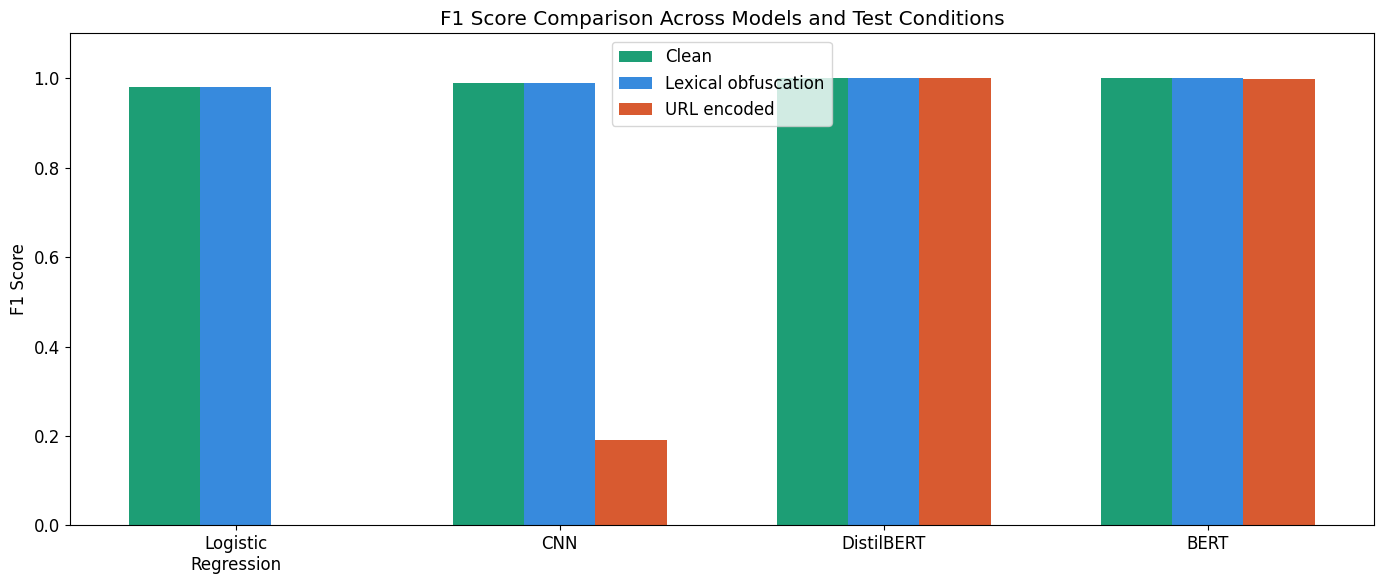

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 12})
models = ['Logistic\nRegression', 'CNN', 'DistilBERT', 'BERT']
clean =   [0.98, 0.99, 1.00, 1.00]
lexical = [0.98, 0.99, 1.00, 1.00]
url =     [0.00, 0.19, 1.00, 0.999]

x = np.arange(len(models))
width = 0.22

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, clean,   width, label='Clean',               color='#1D9E75')
ax.bar(x,         lexical, width, label='Lexical obfuscation', color='#378ADD')
ax.bar(x + width, url,     width, label='URL encoded',         color='#D85A30')

ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_title('F1 Score Comparison Across Models and Test Conditions')
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=300)
plt.show()

Confusion Matrices for URL Encoded SQLi testing of all four models.

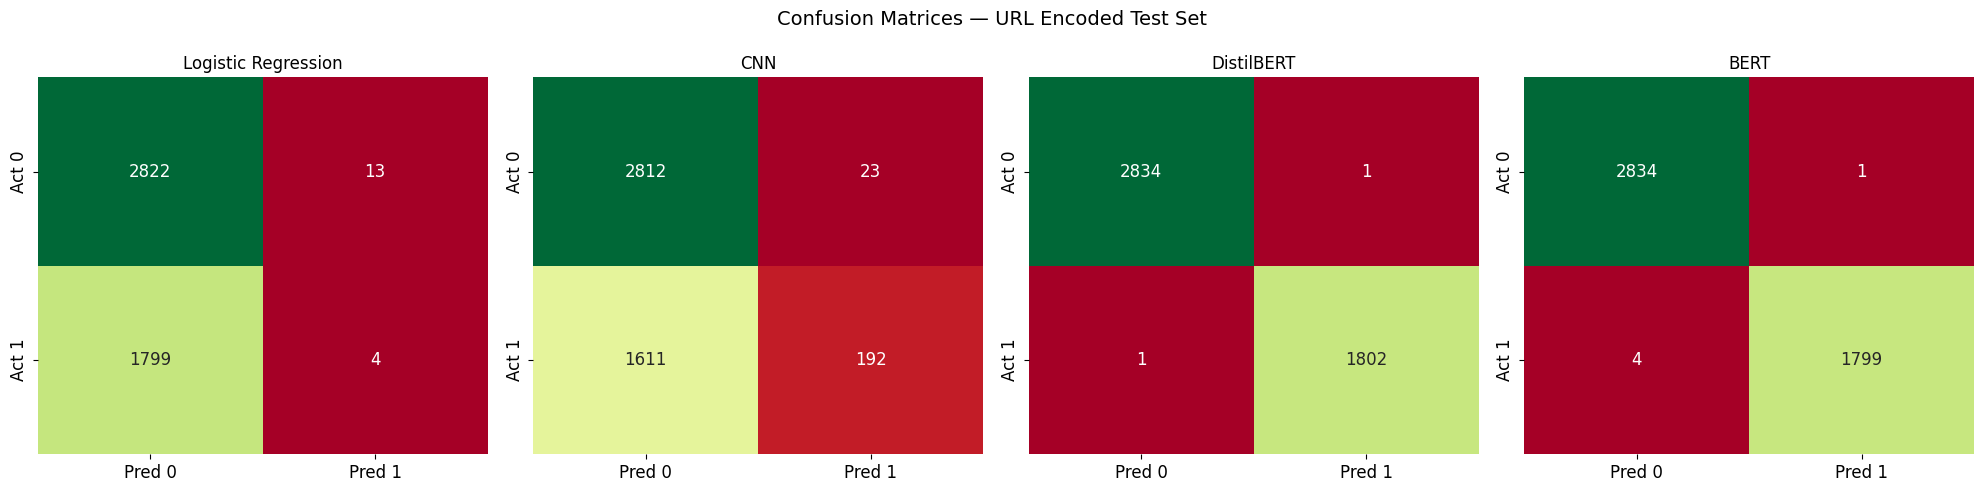

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({'font.size': 12})
cms = [
    np.array([[2822,   13], [1799,    4]]),   # Logistic Regression
    np.array([[2812,   23], [1611,  192]]),   # CNN
    np.array([[2834,    1], [   1, 1802]]),   # DistilBERT
    np.array([[2834,    1], [   4, 1799]])    # BERT
]
titles = ['Logistic Regression', 'CNN', 'DistilBERT', 'BERT']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Act 0',  'Act 1'],
                ax=ax, cbar=False,
                annot_kws={"size": 12})
    ax.set_title(title, fontsize=12)

plt.suptitle('Confusion Matrices — URL Encoded Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()